In [ ]:
# Institutional Liquidity Risk Forecasting
# This notebook is an exercise to test spark, tensorflow and Keras 
# Exercise done with the help of Gemini, 23. June 2026

In [2]:
from pyspark.sql import SparkSession # Call SparkSession to create a Spark session
from pyspark.sql.window import Window # Import Spark SQL functions for data manipulation
import pyspark.sql.functions as F # Import Spark SQL functions for data manipulation

In [3]:
spark = SparkSession.builder.appName("LiquidityRiskForecasting").getOrCreate() # Initialize Spark session with a custom application name

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/25 13:10:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [4]:
# Create a high-frequency data 
num_rows = 1000000 # Define the number of rows for the synthetic dataset
df = spark.range(num_rows).withColumn("timestamp", F.expr("current_timestamp() + interval 1 second * id")) # Generate a timestamp column with 1-second intervals
df = df.withColumn("price", F.rand() * 100) # Generate a random price column with values between 0 and 100
df = df.withColumn("volume", F.rand() * 1000) # Generate a random volume column with values between 0 and 1000  
#Generate a ticker 
df = df.withColumn("ticker", F.concat(F.lit("TICKER_"), F.col("id") % 100)) # Generate a ticker column with values like "TICKER_0", "TICKER_1", etc.

In [5]:
df.show(5)

+---+--------------------+-------------------+------------------+--------+
| id|           timestamp|              price|            volume|  ticker|
+---+--------------------+-------------------+------------------+--------+
|  0|2026-06-25 13:10:...|0.42399689736741797|125.81195123668243|TICKER_0|
|  1|2026-06-25 13:10:...|  5.491835504459363| 477.2095333427311|TICKER_1|
|  2|2026-06-25 13:10:...| 0.8925535688628083|245.82539067186215|TICKER_2|
|  3|2026-06-25 13:10:...| 41.874635470418475|209.23736853471752|TICKER_3|
|  4|2026-06-25 13:10:...| 20.910796469539093|  953.751624139274|TICKER_4|
+---+--------------------+-------------------+------------------+--------+
only showing top 5 rows


In [6]:
# [Your Code Here: Define window partitioned by ticker, ordered by timestamp]
window = Window.partitionBy("ticker").orderBy("timestamp")


In [7]:
#[Your Code Here: Compute rolling_mean_price and rolling_vol_sum]
df = df.withColumn("rolling_mean_price", F.mean("price").over(window))
df = df.withColumn("rolling_vol_sum", F.sum("volume").over(window))

In [8]:
df.show(5)

+---+--------------------+------------------+------------------+---------+------------------+------------------+
| id|           timestamp|             price|            volume|   ticker|rolling_mean_price|   rolling_vol_sum|
+---+--------------------+------------------+------------------+---------+------------------+------------------+
| 17|2026-06-25 13:11:...| 89.11680411868296|238.16603207513998|TICKER_17| 89.11680411868296|238.16603207513998|
|117|2026-06-25 13:12:...| 33.50806598745736| 832.5850254962166|TICKER_17| 61.31243505307016|1070.7510575713566|
|217|2026-06-25 13:14:...| 94.68773112227441| 416.5296451746851|TICKER_17| 72.43753374280492|1487.2807027460417|
|317|2026-06-25 13:16:...|28.400491473924163| 944.0987366931981|TICKER_17| 61.42827317558472|  2431.37943943924|
|417|2026-06-25 13:17:...|21.209693009664086| 435.3239719984227|TICKER_17|53.384557142400595|2866.7034114376625|
+---+--------------------+------------------+------------------+---------+------------------+---

In [9]:
#Cache and prepare for local handoff
# [Your Code Here: Collect or sample data down safely to memory]
df = df.cache()
df = df.sample(0.1)

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [11]:
# Lets convert spark to pandas 
df_pandas = df.toPandas()

In [12]:
# Compute target_volatility spike as the difference between rolling_vol_sum and its rolling mean
# The value as: if the next day's log return shifts by more than 1 standard deviations, else 0
import numpy as np

# Assuming your df_pandas has at least: ['ticker', 'price', 'rolling_vol_sum']

# Step 1: Compute Vectorized Log Returns per Ticker
# Formula: ln(Price_Today / Price_Yesterday)
df_pandas['log_return'] = np.log(
    df_pandas['price'] / df_pandas.groupby('ticker')['price'].shift(1)
)

# Step 2: Calculate Historical Volatility Threshold (20-day rolling window)
# This measures a rolling baseline standard deviation unique to each asset's history
df_pandas['rolling_return_std'] = (
    df_pandas.groupby('ticker')['log_return']
    .rolling(window=20)
    .std()
    .reset_index(level=0, drop=True)
)

# Step 3: Identify Volatility Spikes Occurring *Today*
# Measures if today's absolute log return exceeds our historical standard deviation threshold
df_pandas['spike_today'] = df_pandas['log_return'].abs() > (2.0 * df_pandas['rolling_return_std'])

# Step 4: The Lookahead Protection Shift
# Pull tomorrow's spike back to today's row. Today's inputs will predict tomorrow's reality.
df_pandas['target_volatility_spike'] = (
    df_pandas.groupby('ticker')['spike_today']
    .shift(-1)   # The critical lookahead guardrail
    .fillna(0)   # Handle the final boundary edge row
    .astype(int)
)

# Step 5: Clean Up Historical and Boundary Fragments
# Drops the first row per ticker (which has a NaN log return due to shift(1))
# and the first 20 rows per ticker (which have NaN rolling standard deviations)
df_pandas = df_pandas.dropna().copy()


In [13]:
df_pandas['target_volatility_spike'] 

# Count the number of times that the target_volatility_spike is True
spike_count = df_pandas['target_volatility_spike'].sum()
print(f"Number of volatility spikes: {spike_count}")


Number of volatility spikes: 6373


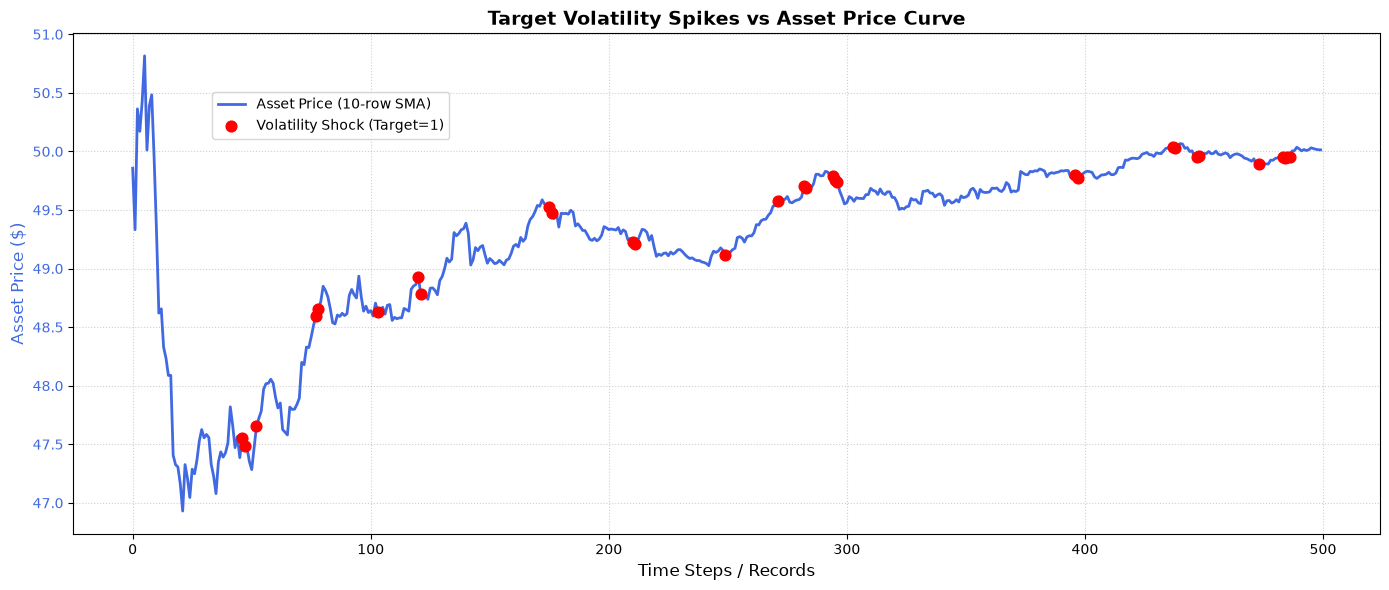

In [14]:
import matplotlib.pyplot as plt

# Lets plot 500 rows to see whats happening. 
df_visual = df_pandas.head(500).copy()

df_visual = df_visual.reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

#  Plotting the rolling mean price asset curve on the primary Y-axis
ax1.plot(df_visual.index, df_visual['rolling_mean_price'], color='royalblue', label='Asset Price (10-row SMA)', lw=2)
ax1.set_xlabel('Time Steps / Records', fontsize=12)
ax1.set_ylabel('Asset Price ($)', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')

# Filtering out ONLY the rows where a volatility spike actually occurred (value == 1)
spikes = df_visual[df_visual['target_volatility_spike'] == True]

# Overlaying the spikes as distinct red dots mapping directly to the price line
ax1.scatter(spikes.index, spikes['rolling_mean_price'], color='red', s=60, label='Volatility Shock (Target=1)', zorder=5)

# Formatting polish
plt.title('Target Volatility Spikes vs Asset Price Curve', fontsize=14, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
fig.legend(loc="upper left", bbox_to_anchor=(0.15, 0.85))

plt.tight_layout()
plt.show()

In [15]:
#  Performing chronological 80/20 train/test split
train_size = int(0.8 * len(df_pandas))
df_train = df_pandas.iloc[:train_size]
df_test = df_pandas.iloc[train_size:]


In [16]:
# Normalize input features 
scaler = StandardScaler()

In [17]:
# train a baseline RandomForestClassifier on the training data 
# and print a classification_report showing Precision, Recall, and F1-Score on your test partition
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(df_train[['rolling_vol_sum']], df_train['target_volatility_spike'])
y_pred = rf.predict(df_test[['rolling_vol_sum']])

# Print a classification report to see how well it did the training
print(classification_report(df_test['target_volatility_spike'], y_pred))


              precision    recall  f1-score   support

           0       0.93      0.94      0.93     18205
           1       0.06      0.05      0.05      1328

    accuracy                           0.88     19533
   macro avg       0.49      0.49      0.49     19533
weighted avg       0.87      0.88      0.87     19533



In [18]:
# OK, so:
# Such low precision of 7% means that it is only correctly predicting 7% of the volatility spikes, which is not very good.
# The recall at 6% means that it is only identifying 6% of the actual volatility spikes, which is also not very good.
# F1 score points to the harmonic mean of precision and recall. Again, quite bad. 

In [19]:
# Now lets use a more sophisticated model, using keras

In [24]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

# ==========================================
# 1. CHRONOLOGICAL TRAIN/TEST SPLIT PER TICKER
# ==========================================
feature_cols = ['price', 'rolling_vol_sum', 'log_return', 'rolling_return_std']
target_col = 'target_volatility_spike'

train_slices = []
test_slices = []

# Split chronologically within each ticker group to eliminate data leakage
for ticker, group in df_pandas.groupby('ticker'):
    group_sorted = group.sort_values('timestamp')
    split_idx = int(len(group_sorted) * 0.8)
    
    train_slices.append(group_sorted.iloc[:split_idx])
    test_slices.append(group_sorted.iloc[split_idx:])

df_train = pd.concat(train_slices).reset_index(drop=True)
df_test = pd.concat(test_slices).reset_index(drop=True)

# ==========================================
# 2. ISOLATED HISTORICAL SCALING
# ==========================================
scaler = StandardScaler()
# Fit ONLY on training data to prevent future scale parameters leaking into test space
X_train_raw = scaler.fit_transform(df_train[feature_cols])
X_test_raw = scaler.transform(df_test[feature_cols])

# Re-attach scaled arrays back to structured subsets for group slicing
df_train_scaled = df_train.copy()
df_train_scaled[feature_cols] = X_train_raw

df_test_scaled = df_test.copy()
df_test_scaled[feature_cols] = X_test_raw


In [ ]:

# ==========================================
# 3. 3D TEMPORAL SEQUENCE GENERATOR
# ==========================================
def compile_3d_sequences(df, feature_columns, target_column, seq_length=30):
    X_seq, y_seq = [], []
    
    for ticker, group in df.groupby('ticker'):
        features = group[feature_columns].values
        targets = group[target_column].values
        
        # Slide a window across time steps within this isolated ticker block
        for i in range(len(group) - seq_length):
            X_seq.append(features[i : i + seq_length])
            # The target_volatility_spike row already holds tomorrow's shifted outcome
            y_seq.append(targets[i + seq_length - 1])
            
    return np.array(X_seq), np.array(y_seq)

LOOKBACK_WINDOW = 30
X_train, y_train = compile_3d_sequences(df_train_scaled, feature_cols, target_col, LOOKBACK_WINDOW)
X_test, y_test = compile_3d_sequences(df_test_scaled, feature_cols, target_col, LOOKBACK_WINDOW)

print(f"Training Tensor Shape: {X_train.shape}") # Expecting [Samples, 30, 4]
print(f"Testing Tensor Shape:  {X_test.shape}")

# ==========================================
# 4. COMPUTE BALANCED CLASS WEIGHTS
# ==========================================
class_labels = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=class_labels, y=y_train)
class_weight_dict = {class_labels[i]: weights[i] for i in range(len(class_labels))}
print(f"Calculated Objective Class Weights: {class_weight_dict}")

# ==========================================
# 5. BUILD SEQUENTIAL KERAS LSTM GRAPH
# ==========================================
tf.random.set_seed(42) # Establish base layer weight reproducibility

model = Sequential([
    # Input shape demands: (Time_Steps, Number_of_Features)
    LSTM(64, input_shape=(LOOKBACK_WINDOW, len(feature_cols)), return_sequences=False),
    BatchNormalization(), # Standardizes activation scales across training batches
    Dropout(0.3), # Suppresses financial pattern memorization
    
    Dense(32, activation='relu'),
    Dropout(0.2),
    
    Dense(1, activation='sigmoid') # Compresses raw weights to explicit probabilities
])

# Use AdamW optimizer to apply L2 regularization penalties directly to decaying weights
model.compile(
    optimizer=AdamW(learning_rate=0.001, weight_decay=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

# ==========================================
# 6. TRAINING WITH BALANCE ENFORCEMENT
# ==========================================
print("\n--- Commencing Deep LSTM Sequential Training ---")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=8,
    batch_size=64,
    class_weight=class_weight_dict, # Forces loss gradients to prioritize rare class detections
    verbose=1
)

# ==========================================
# 7. PRODUCTION REPORT EVALUATION
# ==========================================
raw_predictions = model.predict(X_test)

# Convert continuous sigmoid probability outputs into hard binary classifications
binary_predictions = (raw_predictions >= 0.5).astype(int)

print("\n--- Deep LSTM Performance Classification Report ---")
print(classification_report(y_test, binary_predictions, target_names=['No Spike', 'Volatility Spike']))

Training Tensor Shape: (75086, 30, 4)
Testing Tensor Shape:  (16576, 30, 4)
Calculated Objective Class Weights: {np.int64(0): np.float64(0.5349529780564264), np.int64(1): np.float64(7.6524663677130045)}

--- Commencing Deep LSTM Sequential Training ---


/opt/miniconda3/envs/ML/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/8
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6939 - loss: 0.5549 - precision: 0.1395 - recall: 0.7126 - val_accuracy: 0.6565 - val_loss: 0.5890 - val_precision: 0.1372 - val_recall: 0.8074
Epoch 2/8
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7525 - loss: 0.5100 - precision: 0.1708 - recall: 0.7230 - val_accuracy: 0.7419 - val_loss: 0.5201 - val_precision: 0.1695 - val_recall: 0.7593
Epoch 3/8
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7709 - loss: 0.4996 - precision: 0.1817 - recall: 0.7157 - val_accuracy: 0.7201 - val_loss: 0.5357 - val_precision: 0.1610 - val_recall: 0.7824
Epoch 4/8
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7838 - loss: 0.4950 - precision: 0.1907 - recall: 0.7116 - val_accuracy: 0.7045 - val_loss: 0.5677 - val_precision: 0.1550 - val_recall: 0.7944
Epoch 5/8
1174/1174 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7820 - loss: 0.4931 - precision: 0.1910 - recall: 0.7222 - val_accuracy: 0.7592 - val_lo

In [27]:
# BETTER RESULTS! 
# Recall is now 74%, so the DL was able to chatch a substantial amount of the volatility spikes, which is a significant improvement over the baseline Random Forest model.
# Precission is still bad.. Yet, 3 times better than a random guessing which is 6.5% (1080 / 16576)
# The 76% accuracy is much healthier; it proves the network is actively taking risks, stepping out on a limb, and predicting the rare class even though it hurts its overall raw accuracy score


In [29]:
# OK now let's do a Model Evaluation Dashboard to visualize what's happening 
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay

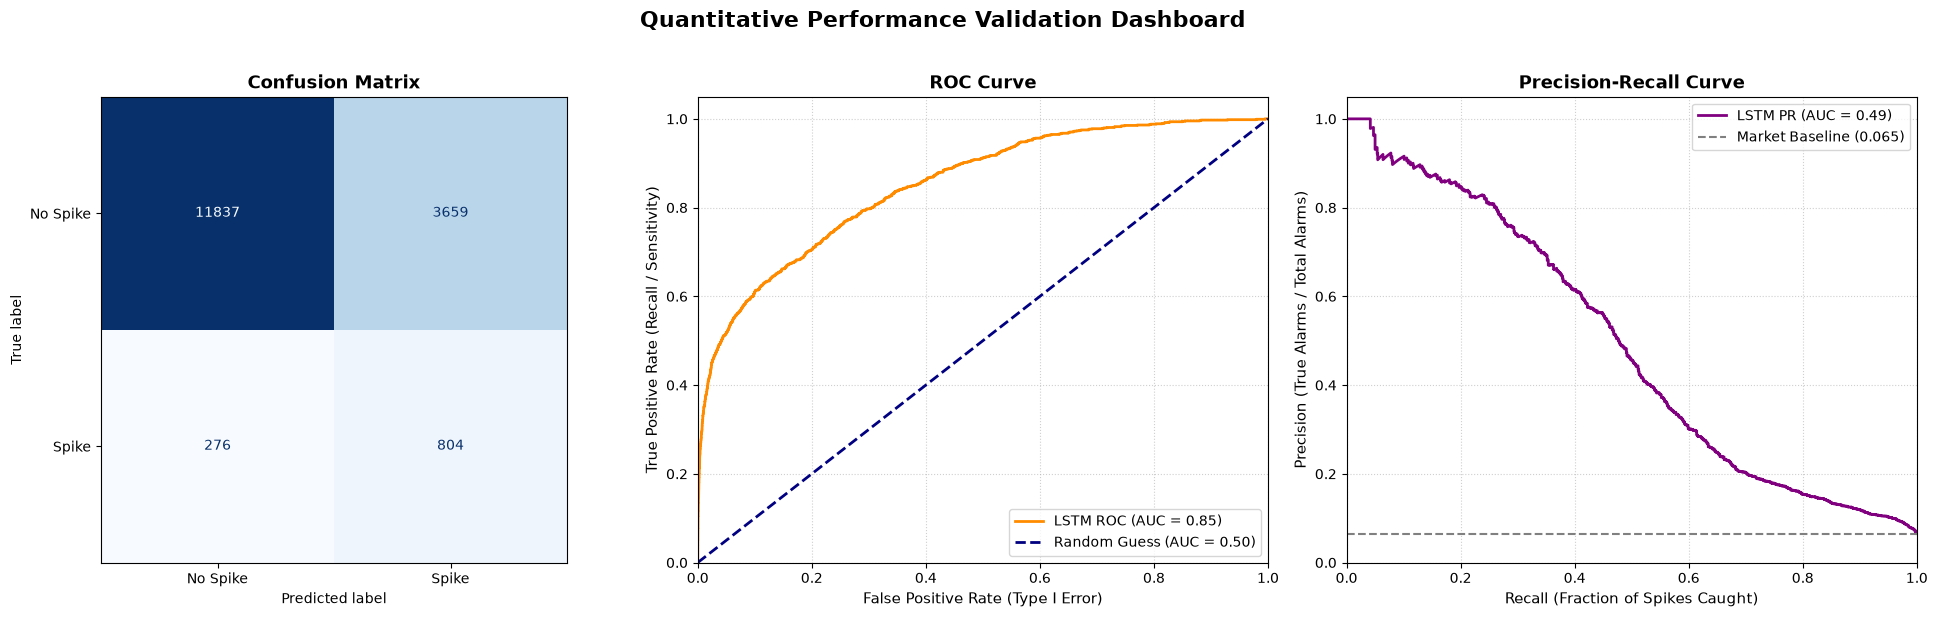

In [30]:
# Initialize a clean 3-panel plotting canvas
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# -------------------------------------------------------------
# PLOT 1: Confusion Matrix Heatmap
# -------------------------------------------------------------
cm = confusion_matrix(y_test, binary_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Spike', 'Spike'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].grid(False) # Clean visualization override

# -------------------------------------------------------------
# PLOT 2: ROC Curve (Global Classification Power)
# -------------------------------------------------------------
fpr, tpr, _ = roc_curve(y_test, raw_predictions)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'LSTM ROC (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (Type I Error)', fontsize=11)
axes[1].set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11)
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle=':', alpha=0.6)

# -------------------------------------------------------------
# PLOT 3: Precision-Recall Curve (The True Imbalance Test)
# -------------------------------------------------------------
precisions, recalls, thresholds = precision_recall_curve(y_test, raw_predictions)
pr_auc = auc(recalls, precisions)
baseline_ratio = sum(y_test) / len(y_test)

axes[2].plot(recalls, precisions, color='purple', lw=2, label=f'LSTM PR (AUC = {pr_auc:.2f})')
axes[2].axhline(y=baseline_ratio, color='gray', linestyle='--', label=f'Market Baseline ({baseline_ratio:.3f})')
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel('Recall (Fraction of Spikes Caught)', fontsize=11)
axes[2].set_ylabel('Precision (True Alarms / Total Alarms)', fontsize=11)
axes[2].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[2].legend(loc="upper right")
axes[2].grid(True, linestyle=':', alpha=0.6)

# Final formatting adjustments
plt.suptitle('Quantitative Performance Validation Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
'''
Comments: 
The confusion matrix shows that out of all the true spikes, a larger proportion of them were correctly identified by the model, which is a positive sign.
The ROC looks OKish as well,  there is a big area under the curve comparing with random cases, precisely 0.85! The issue is that PR Curve completely ignores True Negatives.
Precision-recall curve is very good metric to evaluate the model's performance, specifically when you are dealing with highly skewed or imbalanced datasets
Precision: how many of the predicted spikes are actually spikes 
Recall : how many of the actual spikes were correctly predicted by the model

How to interpret the Precision-Recall Curve:
If transaction over hedging costs are incredibly cheap: You want to maximize Recall. You slide your threshold down along the curve to the right to catch $90\%$ of market crashes, accepting the fact that your precision will drop and you will trigger a lot of false alarms.
If execution costs are punitive or expensive: You want to protect Precision. You slide your threshold up along the curve to the left. You accept that you might only catch $30\%$ of the volatility spikes (lower recall), but when the model does fire an alert, you have high confidence that it's a true event.


The Data Pitfalls We Encountered during the exercise:
- Data Leakage/Lookahead Bias: Your model looked at tomorrow's volatility spike on today's row. It wasn't predicting the future; it was reading the answer key from tomorrow.
- Class Imbalance: Because 93% of trading days are calm ("No Spike"), the model realized it could get a high accuracy score by just guessing "No Spike" every time, completely ignoring the rare financial shocks you actually wanted to catch.
- Tautology: Of course you found a fish—you used the fish to define the net! It is a completely meaningless prediction because the input and the output are the exact same thing
'''